In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/train.csv")

In [3]:
df

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106795,351917269,6,12.0,2147388374,6,12.0,4195677307,10351,LRDA,0,0,0,3,0,0
106796,351917269,7,14.0,2147388374,7,14.0,290896675,10351,LRDA,0,0,0,3,0,0
106797,351917269,8,16.0,2147388374,8,16.0,461435451,10351,LRDA,0,0,0,3,0,0
106798,351917269,9,18.0,2147388374,9,18.0,3786213131,10351,LRDA,0,0,0,3,0,0


## base sanity check

In [4]:
#check nan
df.isna().sum()
df.describe()
# => no nan and apparently no aberrant data

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
count,1.068000e+05,106800.000000,106800.000000,1.068000e+05,106800.000000,106800.000000,1.068000e+05,106800.000000,106800.000000,106800.000000,106800.000000,106800.000000,106800.000000,106800.000000
mean,2.104387e+09,26.286189,118.817228,1.067262e+09,43.733596,520.431404,2.141415e+09,32304.428493,0.878024,1.138783,1.264925,0.948296,1.059185,1.966283
std,1.233371e+09,69.757658,314.557803,6.291475e+08,104.292116,1449.759868,1.241670e+09,18538.196252,1.538873,2.818845,3.131889,2.136799,2.228492,3.621180
min,5.686570e+05,0.000000,0.000000,3.537330e+05,0.000000,0.000000,3.380000e+02,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.026896e+09,1.000000,6.000000,5.238626e+08,2.000000,12.000000,1.067419e+09,16707.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.071326e+09,5.000000,26.000000,1.057904e+09,8.000000,62.000000,2.138332e+09,32068.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.172787e+09,16.000000,82.000000,1.623195e+09,29.000000,394.000000,3.217816e+09,48036.000000,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000
max,4.294958e+09,742.000000,3372.000000,2.147388e+09,1021.000000,17632.000000,4.294934e+09,65494.000000,19.000000,18.000000,16.000000,15.000000,15.000000,25.000000


In [5]:
#check duplicates
df.duplicated().sum()
# => no duplicates

np.int64(0)

## Patients analysis
- how many patients
- how many annotation per patients
- does same patient lead do different ratings

In [6]:
#number of different patients:
print(f"number of patients: {df["patient_id"].nunique()}")


number of patients: 1950


In [7]:
#how many annotation per patient
df["patient_id"].value_counts(normalize= True)*100
# => big imbalance between patients.

patient_id
30631    2.073970
2641     2.045880
35627    1.313670
28330    1.275281
54199    1.264045
           ...   
4539     0.000936
41339    0.000936
43246    0.000936
33103    0.000936
38896    0.000936
Name: proportion, Length: 1950, dtype: float64

In [8]:
#distribution or ratings per patients
df.groupby("patient_id")["expert_consensus"].value_counts().to_csv("./data/rating_per_patient.csv")

In [9]:
df_patients = pd.read_csv("data/rating_per_patient.csv")

In [10]:
df_patients

,patient_id,expert_consensus,count
0,56,Other,60
1,105,Other,38
2,105,GRDA,11
3,105,LPD,5
4,149,GRDA,9
...,...,...,...
3620,65430,Seizure,10
3621,65442,Other,25
3622,65442,Seizure,5
3623,65480,Other,9


In [11]:
df_patients.groupby("patient_id")["count"].sum().sort_values(ascending= False)

patient_id
30631    2215
2641     2185
35627    1403
28330    1362
54199    1350
         ... 
53131       1
24704       1
8278        1
53070       1
16282       1
Name: count, Length: 1950, dtype: int64

In [12]:
def plot_patient_consensus_heatmap(df: pd.DataFrame) -> None:
    # Pivot: patients en lignes, consensus en colonnes, valeurs = count
    pivot = df.pivot_table(index="patient_id", columns="expert_consensus", values="count", aggfunc="sum", fill_value=0)
    # Proportion par patient (normalisation ligne par ligne)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)
    # Tri par total de ratings décroissant (plus grosse somme en haut)
    total_counts = pivot.sum(axis=1).sort_values(ascending=True)  # ascending=True car imshow inverse l'axe y
    pivot_pct = pivot_pct.loc[total_counts.index]
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        pivot_pct,
        ax=ax,
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        linewidths=0,
        cbar_kws={"label": "Proportion (par patient)"},
        annot=len(pivot_pct) <= 50,
        fmt=".0%",
    )
    ax.set_title("Distribution des expert consensus par patient\n(normalisé par patient)", fontsize=14)
    ax.set_xlabel("Expert Consensus")
    ax.set_ylabel("Patient ID")
    ax.xaxis.set_ticks_position("top")
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    plt.show()

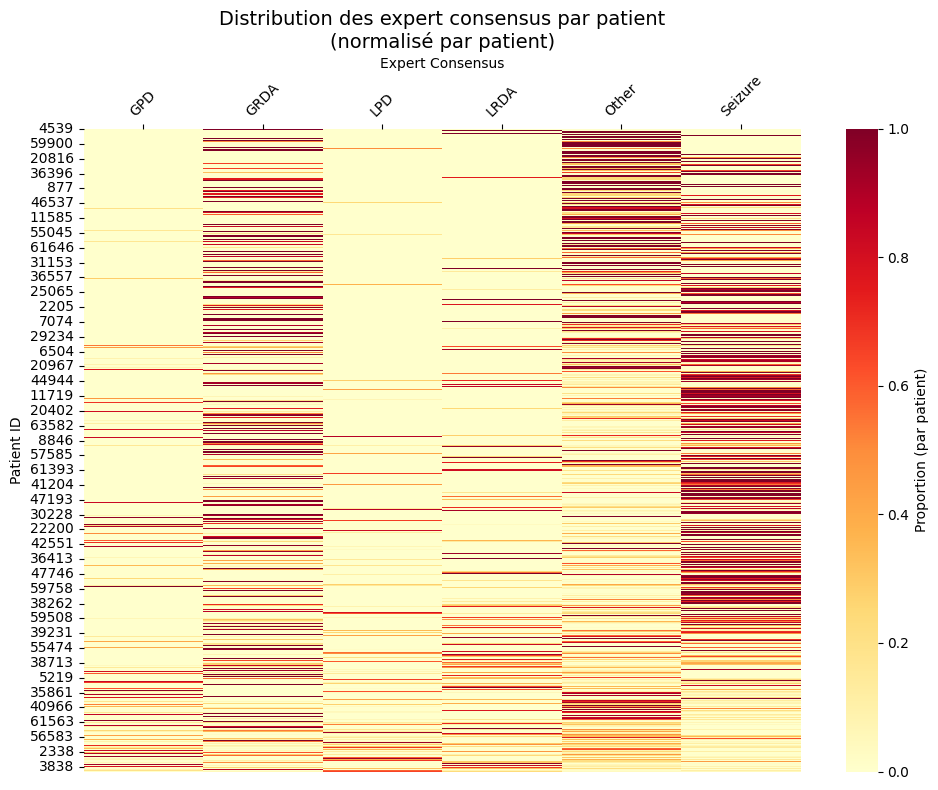

In [13]:
plot_patient_consensus_heatmap(df_patients)

*Conclusion on patients*

- 1950 patients
- big variation of the number of ratings given by patients. 
- same patients have recordings with different ratings (not only "other" vs a clinical rating), but not all patients give "all the ratings". Intuition: distribution of ratings overall different that distribution of ratings within one patient. So selection of patients in a given set may bias the distribution of ratings seen. 


*Actions for project:*
- grouped split to avoid patient leakage
- 

In [14]:
df

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106795,351917269,6,12.0,2147388374,6,12.0,4195677307,10351,LRDA,0,0,0,3,0,0
106796,351917269,7,14.0,2147388374,7,14.0,290896675,10351,LRDA,0,0,0,3,0,0
106797,351917269,8,16.0,2147388374,8,16.0,461435451,10351,LRDA,0,0,0,3,0,0
106798,351917269,9,18.0,2147388374,9,18.0,3786213131,10351,LRDA,0,0,0,3,0,0


## Analysis on vote distribution

- how many voters ? and how many voters per rating? 
- share of mode (mean and per rating)

In [ ]:
vote_cols = ['seizure_vote','lpd_vote','gpd_vote','lrda_vote','grda_vote','other_vote']
df_votes = df[vote_cols]
df_votes["total_votes"] = df_votes.sum(axis= 1)
df_votes["expert_consensus"] = df["expert_consensus"]

In [16]:
#number of voters
df_votes["total_votes"].describe()

count    106800.000000
mean          7.255496
std           5.645681
min           1.000000
25%           3.000000
50%           3.000000
75%          13.000000
max          28.000000
Name: total_votes, dtype: float64

In [17]:
#nomber of voters per rating
df_votes.groupby("expert_consensus")["total_votes"].mean()

expert_consensus
GPD        10.038199
GRDA        6.071099
LPD         8.596325
LRDA        7.012139
Other       9.333688
Seizure     3.477046
Name: total_votes, dtype: float64

In [18]:

df_votes['max_vote_share'] = df_votes[vote_cols].max(axis= 1)/df_votes["total_votes"]

In [20]:
df_votes["max_vote_share"].describe()

count    106800.000000
mean          0.816009
std           0.208296
min           0.200000
25%           0.666667
50%           0.928571
75%           1.000000
max           1.000000
Name: max_vote_share, dtype: float64

In [21]:
df_votes.groupby("expert_consensus")["max_vote_share"].mean()

expert_consensus
GPD        0.733302
GRDA       0.860915
LPD        0.762575
LRDA       0.731774
Other      0.812776
Seizure    0.949322
Name: max_vote_share, dtype: float64

In [23]:
df_eeg = pd.read_parquet("./data/train_eegs/1628180742.parquet")
df_spec = pd.read_parquet("./data/train_spectrograms/353733.parquet")

## Test extraction EEG and spectrogram 

In [25]:
#analysis eeg size
print(f"EEG measurement numbers: {len(df_eeg)}")
print(f"duration, at 200Hz sampling: {len(df_eeg)/200}s")

EEG measurement numbers: 18000
duration, at 200Hz sampling: 90.0s


In [31]:
df[df["spectrogram_id"] == 353733]

,eeg_id,eeg_sub_id,eeg_label_offset_seconds,spectrogram_id,spectrogram_sub_id,spectrogram_label_offset_seconds,label_id,patient_id,expert_consensus,seizure_vote,lpd_vote,gpd_vote,lrda_vote,grda_vote,other_vote
0,1628180742,0,0.0,353733,0,0.0,127492639,42516,Seizure,3,0,0,0,0,0
1,1628180742,1,6.0,353733,1,6.0,3887563113,42516,Seizure,3,0,0,0,0,0
2,1628180742,2,8.0,353733,2,8.0,1142670488,42516,Seizure,3,0,0,0,0,0
3,1628180742,3,18.0,353733,3,18.0,2718991173,42516,Seizure,3,0,0,0,0,0
4,1628180742,4,24.0,353733,4,24.0,3080632009,42516,Seizure,3,0,0,0,0,0
5,1628180742,5,26.0,353733,5,26.0,2413091605,42516,Seizure,3,0,0,0,0,0
6,1628180742,6,30.0,353733,6,30.0,364593930,42516,Seizure,3,0,0,0,0,0
7,1628180742,7,36.0,353733,7,36.0,3811483573,42516,Seizure,3,0,0,0,0,0
8,1628180742,8,40.0,353733,8,40.0,3388718494,42516,Seizure,3,0,0,0,0,0


In [32]:
df_spec

,time,LL_0.59,LL_0.78,LL_0.98,LL_1.17,LL_1.37,LL_1.56,LL_1.76,LL_1.95,LL_2.15,LL_2.34,LL_2.54,LL_2.73,LL_2.93,LL_3.13,LL_3.32,LL_3.52,LL_3.71,LL_3.91,LL_4.1,LL_4.3,LL_4.49,LL_4.69,LL_4.88,LL_5.08,LL_5.27,LL_5.47,LL_5.66,LL_5.86,LL_6.05,LL_6.25,LL_6.45,LL_6.64,LL_6.84,LL_7.03,LL_7.23,LL_7.42,LL_7.62,LL_7.81,LL_8.01,LL_8.2,LL_8.4,LL_8.59,LL_8.79,LL_8.98,LL_9.18,LL_9.38,LL_9.57,LL_9.77,LL_9.96,LL_10.16,LL_10.35,LL_10.55,LL_10.74,LL_10.94,LL_11.13,LL_11.33,LL_11.52,LL_11.72,LL_11.91,LL_12.11,LL_12.3,LL_12.5,LL_12.7,LL_12.89,LL_13.09,LL_13.28,LL_13.48,LL_13.67,LL_13.87,LL_14.06,LL_14.26,LL_14.45,LL_14.65,LL_14.84,LL_15.04,LL_15.23,LL_15.43,LL_15.63,LL_15.82,LL_16.02,LL_16.21,LL_16.41,LL_16.6,LL_16.8,LL_16.99,LL_17.19,LL_17.38,LL_17.58,LL_17.77,LL_17.97,LL_18.16,LL_18.36,LL_18.55,LL_18.75,LL_18.95,LL_19.14,LL_19.34,LL_19.53,LL_19.73,LL_19.92,RL_0.59,RL_0.78,RL_0.98,RL_1.17,RL_1.37,RL_1.56,RL_1.76,RL_1.95,RL_2.15,RL_2.34,RL_2.54,RL_2.73,RL_2.93,RL_3.13,RL_3.32,RL_3.52,RL_3.71,RL_3.91,RL_4.1,RL_4.3,RL_4.49,RL_4.69,RL_4.88,RL_5.08,RL_5.27,RL_5.47,RL_5.66,RL_5.86,RL_6.05,RL_6.25,RL_6.45,RL_6.64,RL_6.84,RL_7.03,RL_7.23,RL_7.42,RL_7.62,RL_7.81,RL_8.01,RL_8.2,RL_8.4,RL_8.59,RL_8.79,RL_8.98,RL_9.18,RL_9.38,RL_9.57,RL_9.77,RL_9.96,RL_10.16,RL_10.35,RL_10.55,RL_10.74,RL_10.94,RL_11.13,RL_11.33,RL_11.52,RL_11.72,RL_11.91,RL_12.11,RL_12.3,RL_12.5,RL_12.7,RL_12.89,RL_13.09,RL_13.28,RL_13.48,RL_13.67,RL_13.87,RL_14.06,RL_14.26,RL_14.45,RL_14.65,RL_14.84,RL_15.04,RL_15.23,RL_15.43,RL_15.63,RL_15.82,RL_16.02,RL_16.21,RL_16.41,RL_16.6,RL_16.8,RL_16.99,RL_17.19,RL_17.38,RL_17.58,RL_17.77,RL_17.97,RL_18.16,RL_18.36,RL_18.55,RL_18.75,RL_18.95,RL_19.14,RL_19.34,RL_19.53,RL_19.73,RL_19.92,LP_0.59,LP_0.78,LP_0.98,LP_1.17,LP_1.37,LP_1.56,LP_1.76,LP_1.95,LP_2.15,LP_2.34,LP_2.54,LP_2.73,LP_2.93,LP_3.13,LP_3.32,LP_3.52,LP_3.71,LP_3.91,LP_4.1,LP_4.3,LP_4.49,LP_4.69,LP_4.88,LP_5.08,LP_5.27,LP_5.47,LP_5.66,LP_5.86,LP_6.05,LP_6.25,LP_6.45,LP_6.64,LP_6.84,LP_7.03,LP_7.23,LP_7.42,LP_7.62,LP_7.81,LP_8.01,LP_8.2,LP_8.4,LP_8.59,LP_8.79,LP_8.98,LP_9.18,LP_9.38,LP_9.57,LP_9.77,LP_9.96,LP_10.16,LP_10.35,LP_10.55,LP_10.74,LP_10.94,LP_11.13,LP_11.33,LP_11.52,LP_11.72,LP_11.91,LP_12.11,LP_12.3,LP_12.5,LP_12.7,LP_12.89,LP_13.09,LP_13.28,LP_13.48,LP_13.67,LP_13.87,LP_14.06,LP_14.26,LP_14.45,LP_14.65,LP_14.84,LP_15.04,LP_15.23,LP_15.43,LP_15.63,LP_15.82,LP_16.02,LP_16.21,LP_16.41,LP_16.6,LP_16.8,LP_16.99,LP_17.19,LP_17.38,LP_17.58,LP_17.77,LP_17.97,LP_18.16,LP_18.36,LP_18.55,LP_18.75,LP_18.95,LP_19.14,LP_19.34,LP_19.53,LP_19.73,LP_19.92,RP_0.59,RP_0.78,RP_0.98,RP_1.17,RP_1.37,RP_1.56,RP_1.76,RP_1.95,RP_2.15,RP_2.34,RP_2.54,RP_2.73,RP_2.93,RP_3.13,RP_3.32,RP_3.52,RP_3.71,RP_3.91,RP_4.1,RP_4.3,RP_4.49,RP_4.69,RP_4.88,RP_5.08,RP_5.27,RP_5.47,RP_5.66,RP_5.86,RP_6.05,RP_6.25,RP_6.45,RP_6.64,RP_6.84,RP_7.03,RP_7.23,RP_7.42,RP_7.62,RP_7.81,RP_8.01,RP_8.2,RP_8.4,RP_8.59,RP_8.79,RP_8.98,RP_9.18,RP_9.38,RP_9.57,RP_9.77,RP_9.96,RP_10.16,RP_10.35,RP_10.55,RP_10.74,RP_10.94,RP_11.13,RP_11.33,RP_11.52,RP_11.72,RP_11.91,RP_12.11,RP_12.3,RP_12.5,RP_12.7,RP_12.89,RP_13.09,RP_13.28,RP_13.48,RP_13.67,RP_13.87,RP_14.06,RP_14.26,RP_14.45,RP_14.65,RP_14.84,RP_15.04,RP_15.23,RP_15.43,RP_15.63,RP_15.82,RP_16.02,RP_16.21,RP_16.41,RP_16.6,RP_16.8,RP_16.99,RP_17.19,RP_17.38,RP_17.58,RP_17.77,RP_17.97,RP_18.16,RP_18.36,RP_18.55,RP_18.75,RP_18.95,RP_19.14,RP_19.34,RP_19.53,RP_19.73,RP_19.92
0,1,4.26,10.98,9.05,13.65,11.49,8.930000,18.840000,19.26,19.240000,19.049999,8.820000,5.400000,6.47,6.08,3.94,7.67,4.23,5.86,5.23,3.69,2.46,2.32,2.57,3.32,4.01,2.46,3.75,3.61,3.38,2.97,2.61,2.00,1.53,1.70,1.81,1.19,1.03,0.89,1.14,1.16,1.03,0.91,0.43,0.47,0.49,0.52,0.44,0.30,0.37,0.32,0.36,0.39,0.44,0.43,0.38,0.40,0.30,0.37,0.36,0.29,0.29,0.31,0.22,0.23,0.35,0.25,0.32,0.34,0.31,0.32,0.36,0.33,0.33,0.24,0.24,0.27,0.24,0.18,0.36,0.34,0.34,0.40,0.33,0.30,0.31,0.18,0.17,0.16,0.22,0.22,0.21,0.13,0.08,0.19,0.25,0.26,0.27,0.20,0.23,0.21,6.29,6.56,5.08,5.28,3.95,3.27,5.85,6.10,4.60,5.77,4.45,2.85,2.42,2.38,2.32,2.11,1.70,1.55,0

In [30]:
df_spec.shape

(320, 401)

In [33]:
df_spec

Index(['time', 'LL_0.59', 'LL_0.78', 'LL_0.98', 'LL_1.17', 'LL_1.37',
       'LL_1.56', 'LL_1.76', 'LL_1.95', 'LL_2.15',
       ...
       'RP_18.16', 'RP_18.36', 'RP_18.55', 'RP_18.75', 'RP_18.95', 'RP_19.14',
       'RP_19.34', 'RP_19.53', 'RP_19.73', 'RP_19.92'],
      dtype='str', length=401)

In [ ]:
regions = ["LL_", "RL_", "LP_", "RP_"]
spectrogram = np.zeros((df_spec.shape[0], 4, 100))
for i,region in enumerate(regions):

    selected_cols = [c for c in df_spec.columns if c.startswith(region)]
    selected_df = df_spec[selected_cols]
    single_region_np = selected_df.to_numpy()
    spectrogram[:,i,:] = single_region_np


In [43]:
spectrogram = spectrogram.transpose((1,2,0))

In [44]:
spectrogram.shape

(4, 100, 320)

In [45]:
def plot_spectrogram(spec: np.ndarray, sr: int = 1, hop: int = 1, title: str = "Spectrogram") -> None:
    """
    spec  : ndarray de shape (n_freqs, n_times)
    sr    : sample rate en Hz (pour l'axe temps)
    hop   : hop length en samples (pour l'axe temps)
    """
    fig, ax = plt.subplots(figsize=(12, 4))

    times = np.arange(spec.shape[1]) * hop / sr
    freqs = np.arange(spec.shape[0])

    img = ax.imshow(
        spec,
        aspect="auto",
        origin="lower",         # fréquences basses en bas
        cmap="inferno",
        extent=[times[0], times[-1], freqs[0], freqs[-1]],
    )

    plt.colorbar(img, ax=ax, label="Amplitude")
    ax.set_title(title)
    ax.set_xlabel("Temps (s)")
    ax.set_ylabel("Fréquence (Hz)")
    plt.tight_layout()
    plt.show()

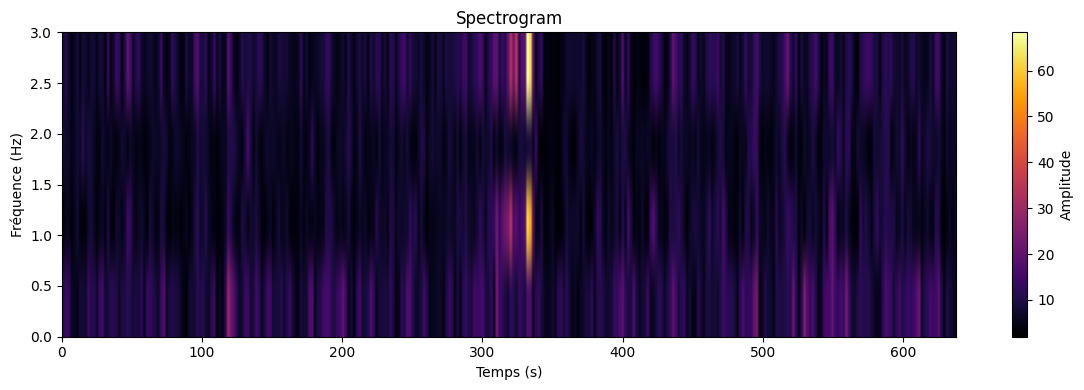

In [51]:
plot_spectrogram(spec= spectrogram[:,4,:], hop= 2)

## test on values

In [52]:
df_spec

,time,LL_0.59,LL_0.78,LL_0.98,LL_1.17,LL_1.37,LL_1.56,LL_1.76,LL_1.95,LL_2.15,LL_2.34,LL_2.54,LL_2.73,LL_2.93,LL_3.13,LL_3.32,LL_3.52,LL_3.71,LL_3.91,LL_4.1,LL_4.3,LL_4.49,LL_4.69,LL_4.88,LL_5.08,LL_5.27,LL_5.47,LL_5.66,LL_5.86,LL_6.05,LL_6.25,LL_6.45,LL_6.64,LL_6.84,LL_7.03,LL_7.23,LL_7.42,LL_7.62,LL_7.81,LL_8.01,LL_8.2,LL_8.4,LL_8.59,LL_8.79,LL_8.98,LL_9.18,LL_9.38,LL_9.57,LL_9.77,LL_9.96,LL_10.16,LL_10.35,LL_10.55,LL_10.74,LL_10.94,LL_11.13,LL_11.33,LL_11.52,LL_11.72,LL_11.91,LL_12.11,LL_12.3,LL_12.5,LL_12.7,LL_12.89,LL_13.09,LL_13.28,LL_13.48,LL_13.67,LL_13.87,LL_14.06,LL_14.26,LL_14.45,LL_14.65,LL_14.84,LL_15.04,LL_15.23,LL_15.43,LL_15.63,LL_15.82,LL_16.02,LL_16.21,LL_16.41,LL_16.6,LL_16.8,LL_16.99,LL_17.19,LL_17.38,LL_17.58,LL_17.77,LL_17.97,LL_18.16,LL_18.36,LL_18.55,LL_18.75,LL_18.95,LL_19.14,LL_19.34,LL_19.53,LL_19.73,LL_19.92,RL_0.59,RL_0.78,RL_0.98,RL_1.17,RL_1.37,RL_1.56,RL_1.76,RL_1.95,RL_2.15,RL_2.34,RL_2.54,RL_2.73,RL_2.93,RL_3.13,RL_3.32,RL_3.52,RL_3.71,RL_3.91,RL_4.1,RL_4.3,RL_4.49,RL_4.69,RL_4.88,RL_5.08,RL_5.27,RL_5.47,RL_5.66,RL_5.86,RL_6.05,RL_6.25,RL_6.45,RL_6.64,RL_6.84,RL_7.03,RL_7.23,RL_7.42,RL_7.62,RL_7.81,RL_8.01,RL_8.2,RL_8.4,RL_8.59,RL_8.79,RL_8.98,RL_9.18,RL_9.38,RL_9.57,RL_9.77,RL_9.96,RL_10.16,RL_10.35,RL_10.55,RL_10.74,RL_10.94,RL_11.13,RL_11.33,RL_11.52,RL_11.72,RL_11.91,RL_12.11,RL_12.3,RL_12.5,RL_12.7,RL_12.89,RL_13.09,RL_13.28,RL_13.48,RL_13.67,RL_13.87,RL_14.06,RL_14.26,RL_14.45,RL_14.65,RL_14.84,RL_15.04,RL_15.23,RL_15.43,RL_15.63,RL_15.82,RL_16.02,RL_16.21,RL_16.41,RL_16.6,RL_16.8,RL_16.99,RL_17.19,RL_17.38,RL_17.58,RL_17.77,RL_17.97,RL_18.16,RL_18.36,RL_18.55,RL_18.75,RL_18.95,RL_19.14,RL_19.34,RL_19.53,RL_19.73,RL_19.92,LP_0.59,LP_0.78,LP_0.98,LP_1.17,LP_1.37,LP_1.56,LP_1.76,LP_1.95,LP_2.15,LP_2.34,LP_2.54,LP_2.73,LP_2.93,LP_3.13,LP_3.32,LP_3.52,LP_3.71,LP_3.91,LP_4.1,LP_4.3,LP_4.49,LP_4.69,LP_4.88,LP_5.08,LP_5.27,LP_5.47,LP_5.66,LP_5.86,LP_6.05,LP_6.25,LP_6.45,LP_6.64,LP_6.84,LP_7.03,LP_7.23,LP_7.42,LP_7.62,LP_7.81,LP_8.01,LP_8.2,LP_8.4,LP_8.59,LP_8.79,LP_8.98,LP_9.18,LP_9.38,LP_9.57,LP_9.77,LP_9.96,LP_10.16,LP_10.35,LP_10.55,LP_10.74,LP_10.94,LP_11.13,LP_11.33,LP_11.52,LP_11.72,LP_11.91,LP_12.11,LP_12.3,LP_12.5,LP_12.7,LP_12.89,LP_13.09,LP_13.28,LP_13.48,LP_13.67,LP_13.87,LP_14.06,LP_14.26,LP_14.45,LP_14.65,LP_14.84,LP_15.04,LP_15.23,LP_15.43,LP_15.63,LP_15.82,LP_16.02,LP_16.21,LP_16.41,LP_16.6,LP_16.8,LP_16.99,LP_17.19,LP_17.38,LP_17.58,LP_17.77,LP_17.97,LP_18.16,LP_18.36,LP_18.55,LP_18.75,LP_18.95,LP_19.14,LP_19.34,LP_19.53,LP_19.73,LP_19.92,RP_0.59,RP_0.78,RP_0.98,RP_1.17,RP_1.37,RP_1.56,RP_1.76,RP_1.95,RP_2.15,RP_2.34,RP_2.54,RP_2.73,RP_2.93,RP_3.13,RP_3.32,RP_3.52,RP_3.71,RP_3.91,RP_4.1,RP_4.3,RP_4.49,RP_4.69,RP_4.88,RP_5.08,RP_5.27,RP_5.47,RP_5.66,RP_5.86,RP_6.05,RP_6.25,RP_6.45,RP_6.64,RP_6.84,RP_7.03,RP_7.23,RP_7.42,RP_7.62,RP_7.81,RP_8.01,RP_8.2,RP_8.4,RP_8.59,RP_8.79,RP_8.98,RP_9.18,RP_9.38,RP_9.57,RP_9.77,RP_9.96,RP_10.16,RP_10.35,RP_10.55,RP_10.74,RP_10.94,RP_11.13,RP_11.33,RP_11.52,RP_11.72,RP_11.91,RP_12.11,RP_12.3,RP_12.5,RP_12.7,RP_12.89,RP_13.09,RP_13.28,RP_13.48,RP_13.67,RP_13.87,RP_14.06,RP_14.26,RP_14.45,RP_14.65,RP_14.84,RP_15.04,RP_15.23,RP_15.43,RP_15.63,RP_15.82,RP_16.02,RP_16.21,RP_16.41,RP_16.6,RP_16.8,RP_16.99,RP_17.19,RP_17.38,RP_17.58,RP_17.77,RP_17.97,RP_18.16,RP_18.36,RP_18.55,RP_18.75,RP_18.95,RP_19.14,RP_19.34,RP_19.53,RP_19.73,RP_19.92
0,1,4.26,10.98,9.05,13.65,11.49,8.930000,18.840000,19.26,19.240000,19.049999,8.820000,5.400000,6.47,6.08,3.94,7.67,4.23,5.86,5.23,3.69,2.46,2.32,2.57,3.32,4.01,2.46,3.75,3.61,3.38,2.97,2.61,2.00,1.53,1.70,1.81,1.19,1.03,0.89,1.14,1.16,1.03,0.91,0.43,0.47,0.49,0.52,0.44,0.30,0.37,0.32,0.36,0.39,0.44,0.43,0.38,0.40,0.30,0.37,0.36,0.29,0.29,0.31,0.22,0.23,0.35,0.25,0.32,0.34,0.31,0.32,0.36,0.33,0.33,0.24,0.24,0.27,0.24,0.18,0.36,0.34,0.34,0.40,0.33,0.30,0.31,0.18,0.17,0.16,0.22,0.22,0.21,0.13,0.08,0.19,0.25,0.26,0.27,0.20,0.23,0.21,6.29,6.56,5.08,5.28,3.95,3.27,5.85,6.10,4.60,5.77,4.45,2.85,2.42,2.38,2.32,2.11,1.70,1.55,0

In [63]:
df_spec["RP_18.36"].describe()

count    320.000000
mean       0.310188
std        0.474795
min        0.040000
25%        0.130000
50%        0.190000
75%        0.320000
max        5.480000
Name: RP_18.36, dtype: float64

In [56]:
df_spec.skew().sort_values(ascending= False)

LP_18.36    9.047021
RL_3.13     8.461914
LP_17.97    8.447282
LP_18.55    8.378519
LP_18.16    8.228558
              ...   
LL_8.4      0.450060
LL_3.52     0.439084
LP_5.86     0.405699
LP_2.93     0.307539
time        0.000000
Length: 401, dtype: float64

<Axes: >

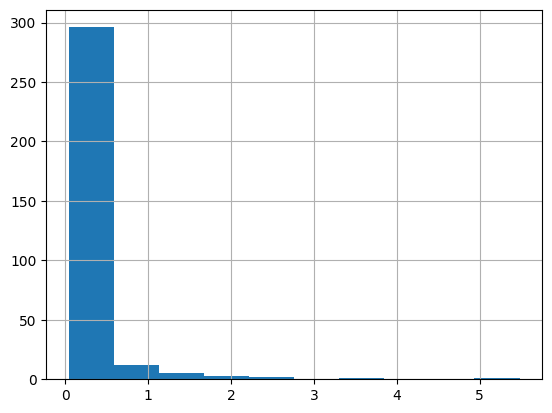

In [60]:
df_spec["RP_18.36"].hist()

In [57]:
df_spec_log = np.log1p(df_spec)

In [62]:
df_spec_log["RP_18.36"].describe()

count    320.000000
mean       0.237168
std        0.222340
min        0.039221
25%        0.122218
50%        0.173953
75%        0.277632
max        1.868721
Name: RP_18.36, dtype: float64

In [59]:
df_spec_log.skew().sort_values(ascending = False)

LP_18.36    5.229592
LP_18.55    5.159939
LL_16.8     5.144710
LL_15.63    4.904352
LL_15.82    4.895525
              ...   
LL_2.54    -0.469631
LL_2.73    -0.476490
LP_2.93    -0.577226
LP_2.73    -0.587418
time       -1.739012
Length: 401, dtype: float64

<Axes: >

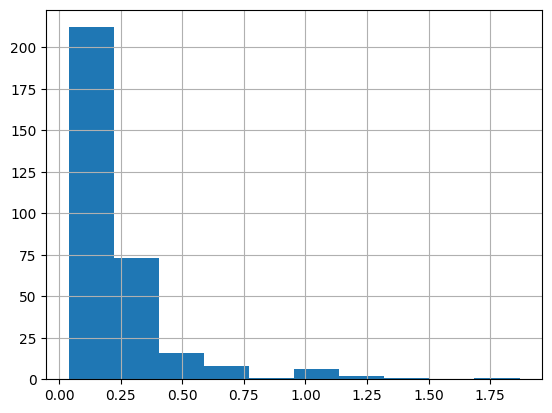

In [61]:
df_spec_log["RP_18.36"].hist()

## computation of dummy baseline
- calculation using the average distribution of the dataset as predicted distribution. 

In [65]:
vote_cols = ['seizure_vote','lpd_vote','gpd_vote','lrda_vote','grda_vote','other_vote']
#calculate mean vote distribution dividing sume of vote for each output by total number of vote at each row
probs = df[vote_cols].div(df[vote_cols].sum(axis= 1), axis= 0)

#mean distribution
mean_dist = probs.mean(axis= 0)

In [68]:
mean_dist

seizure_vote    0.208319
lpd_vote        0.132120
gpd_vote        0.128533
lrda_vote       0.138913
grda_vote       0.179294
other_vote      0.212822
dtype: float64

In [69]:
#use the fact that scipy entropy calculate KL(p,q)
from scipy.stats import entropy

kl_baseline = probs.apply(lambda x: entropy(x, mean_dist), axis= 1)
print(f"baseline kl is: {kl_baseline.mean()}")

baseline kl is: 1.3801088872115663


In [70]:
df_spec

,time,LL_0.59,LL_0.78,LL_0.98,LL_1.17,LL_1.37,LL_1.56,LL_1.76,LL_1.95,LL_2.15,LL_2.34,LL_2.54,LL_2.73,LL_2.93,LL_3.13,LL_3.32,LL_3.52,LL_3.71,LL_3.91,LL_4.1,LL_4.3,LL_4.49,LL_4.69,LL_4.88,LL_5.08,LL_5.27,LL_5.47,LL_5.66,LL_5.86,LL_6.05,LL_6.25,LL_6.45,LL_6.64,LL_6.84,LL_7.03,LL_7.23,LL_7.42,LL_7.62,LL_7.81,LL_8.01,LL_8.2,LL_8.4,LL_8.59,LL_8.79,LL_8.98,LL_9.18,LL_9.38,LL_9.57,LL_9.77,LL_9.96,LL_10.16,LL_10.35,LL_10.55,LL_10.74,LL_10.94,LL_11.13,LL_11.33,LL_11.52,LL_11.72,LL_11.91,LL_12.11,LL_12.3,LL_12.5,LL_12.7,LL_12.89,LL_13.09,LL_13.28,LL_13.48,LL_13.67,LL_13.87,LL_14.06,LL_14.26,LL_14.45,LL_14.65,LL_14.84,LL_15.04,LL_15.23,LL_15.43,LL_15.63,LL_15.82,LL_16.02,LL_16.21,LL_16.41,LL_16.6,LL_16.8,LL_16.99,LL_17.19,LL_17.38,LL_17.58,LL_17.77,LL_17.97,LL_18.16,LL_18.36,LL_18.55,LL_18.75,LL_18.95,LL_19.14,LL_19.34,LL_19.53,LL_19.73,LL_19.92,RL_0.59,RL_0.78,RL_0.98,RL_1.17,RL_1.37,RL_1.56,RL_1.76,RL_1.95,RL_2.15,RL_2.34,RL_2.54,RL_2.73,RL_2.93,RL_3.13,RL_3.32,RL_3.52,RL_3.71,RL_3.91,RL_4.1,RL_4.3,RL_4.49,RL_4.69,RL_4.88,RL_5.08,RL_5.27,RL_5.47,RL_5.66,RL_5.86,RL_6.05,RL_6.25,RL_6.45,RL_6.64,RL_6.84,RL_7.03,RL_7.23,RL_7.42,RL_7.62,RL_7.81,RL_8.01,RL_8.2,RL_8.4,RL_8.59,RL_8.79,RL_8.98,RL_9.18,RL_9.38,RL_9.57,RL_9.77,RL_9.96,RL_10.16,RL_10.35,RL_10.55,RL_10.74,RL_10.94,RL_11.13,RL_11.33,RL_11.52,RL_11.72,RL_11.91,RL_12.11,RL_12.3,RL_12.5,RL_12.7,RL_12.89,RL_13.09,RL_13.28,RL_13.48,RL_13.67,RL_13.87,RL_14.06,RL_14.26,RL_14.45,RL_14.65,RL_14.84,RL_15.04,RL_15.23,RL_15.43,RL_15.63,RL_15.82,RL_16.02,RL_16.21,RL_16.41,RL_16.6,RL_16.8,RL_16.99,RL_17.19,RL_17.38,RL_17.58,RL_17.77,RL_17.97,RL_18.16,RL_18.36,RL_18.55,RL_18.75,RL_18.95,RL_19.14,RL_19.34,RL_19.53,RL_19.73,RL_19.92,LP_0.59,LP_0.78,LP_0.98,LP_1.17,LP_1.37,LP_1.56,LP_1.76,LP_1.95,LP_2.15,LP_2.34,LP_2.54,LP_2.73,LP_2.93,LP_3.13,LP_3.32,LP_3.52,LP_3.71,LP_3.91,LP_4.1,LP_4.3,LP_4.49,LP_4.69,LP_4.88,LP_5.08,LP_5.27,LP_5.47,LP_5.66,LP_5.86,LP_6.05,LP_6.25,LP_6.45,LP_6.64,LP_6.84,LP_7.03,LP_7.23,LP_7.42,LP_7.62,LP_7.81,LP_8.01,LP_8.2,LP_8.4,LP_8.59,LP_8.79,LP_8.98,LP_9.18,LP_9.38,LP_9.57,LP_9.77,LP_9.96,LP_10.16,LP_10.35,LP_10.55,LP_10.74,LP_10.94,LP_11.13,LP_11.33,LP_11.52,LP_11.72,LP_11.91,LP_12.11,LP_12.3,LP_12.5,LP_12.7,LP_12.89,LP_13.09,LP_13.28,LP_13.48,LP_13.67,LP_13.87,LP_14.06,LP_14.26,LP_14.45,LP_14.65,LP_14.84,LP_15.04,LP_15.23,LP_15.43,LP_15.63,LP_15.82,LP_16.02,LP_16.21,LP_16.41,LP_16.6,LP_16.8,LP_16.99,LP_17.19,LP_17.38,LP_17.58,LP_17.77,LP_17.97,LP_18.16,LP_18.36,LP_18.55,LP_18.75,LP_18.95,LP_19.14,LP_19.34,LP_19.53,LP_19.73,LP_19.92,RP_0.59,RP_0.78,RP_0.98,RP_1.17,RP_1.37,RP_1.56,RP_1.76,RP_1.95,RP_2.15,RP_2.34,RP_2.54,RP_2.73,RP_2.93,RP_3.13,RP_3.32,RP_3.52,RP_3.71,RP_3.91,RP_4.1,RP_4.3,RP_4.49,RP_4.69,RP_4.88,RP_5.08,RP_5.27,RP_5.47,RP_5.66,RP_5.86,RP_6.05,RP_6.25,RP_6.45,RP_6.64,RP_6.84,RP_7.03,RP_7.23,RP_7.42,RP_7.62,RP_7.81,RP_8.01,RP_8.2,RP_8.4,RP_8.59,RP_8.79,RP_8.98,RP_9.18,RP_9.38,RP_9.57,RP_9.77,RP_9.96,RP_10.16,RP_10.35,RP_10.55,RP_10.74,RP_10.94,RP_11.13,RP_11.33,RP_11.52,RP_11.72,RP_11.91,RP_12.11,RP_12.3,RP_12.5,RP_12.7,RP_12.89,RP_13.09,RP_13.28,RP_13.48,RP_13.67,RP_13.87,RP_14.06,RP_14.26,RP_14.45,RP_14.65,RP_14.84,RP_15.04,RP_15.23,RP_15.43,RP_15.63,RP_15.82,RP_16.02,RP_16.21,RP_16.41,RP_16.6,RP_16.8,RP_16.99,RP_17.19,RP_17.38,RP_17.58,RP_17.77,RP_17.97,RP_18.16,RP_18.36,RP_18.55,RP_18.75,RP_18.95,RP_19.14,RP_19.34,RP_19.53,RP_19.73,RP_19.92
0,1,4.26,10.98,9.05,13.65,11.49,8.930000,18.840000,19.26,19.240000,19.049999,8.820000,5.400000,6.47,6.08,3.94,7.67,4.23,5.86,5.23,3.69,2.46,2.32,2.57,3.32,4.01,2.46,3.75,3.61,3.38,2.97,2.61,2.00,1.53,1.70,1.81,1.19,1.03,0.89,1.14,1.16,1.03,0.91,0.43,0.47,0.49,0.52,0.44,0.30,0.37,0.32,0.36,0.39,0.44,0.43,0.38,0.40,0.30,0.37,0.36,0.29,0.29,0.31,0.22,0.23,0.35,0.25,0.32,0.34,0.31,0.32,0.36,0.33,0.33,0.24,0.24,0.27,0.24,0.18,0.36,0.34,0.34,0.40,0.33,0.30,0.31,0.18,0.17,0.16,0.22,0.22,0.21,0.13,0.08,0.19,0.25,0.26,0.27,0.20,0.23,0.21,6.29,6.56,5.08,5.28,3.95,3.27,5.85,6.10,4.60,5.77,4.45,2.85,2.42,2.38,2.32,2.11,1.70,1.55,0

In [72]:
offset = 8
start_time = offset + 1  # premier centre >= offset
end_time = start_time + 600  # 300 steps × 2s
df_spec[(df_spec["time"] >= start_time) & (df_spec["time"] < end_time)].shape

(300, 401)